# Ex. No: 07 
## Lane Detection using Hough Transform.

**Name :** Megha S   **Reg. No :** 212224230157   

In [47]:
# Import 
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [48]:
# Read the image using OpenCV

image=cv2.imread('lan_img1.jpg')

In [49]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [50]:
# Convert to grayscale.

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)



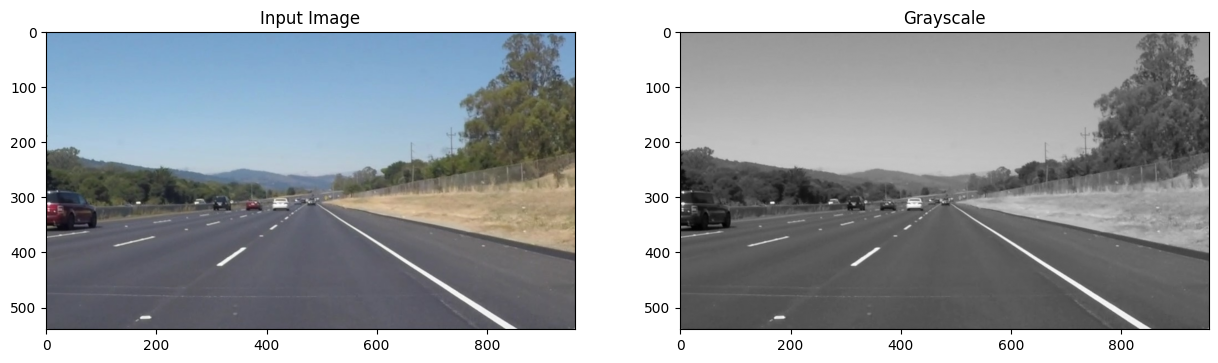

In [51]:
# Display the image using Matplotlib

plt.figure(figsize = (15, 10))
plt.subplot(1,2,1); plt.imshow(image_rgb);plt.title('Input Image');
plt.subplot(1,2,2); plt.imshow(gray_image, cmap = 'gray');      
plt.title('Grayscale');

In [52]:
# Use global threshold based on grayscale intensity.
threshold  = 127
_, thresh = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

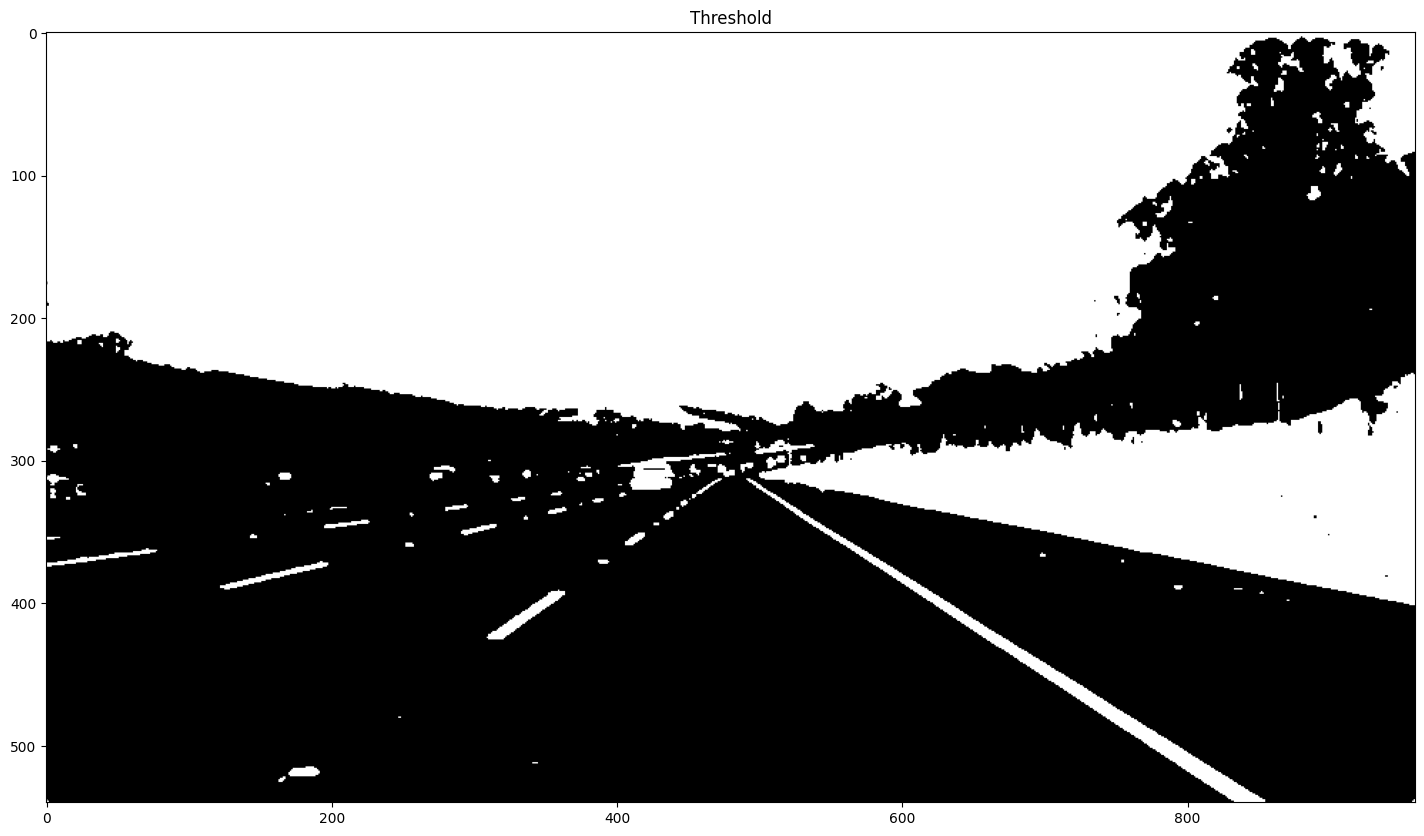

In [53]:
# Display images.
plt.figure(figsize = (20, 10))
plt.subplot(1,1,1); 
plt.imshow(thresh, cmap = 'gray');
plt.title('Threshold');



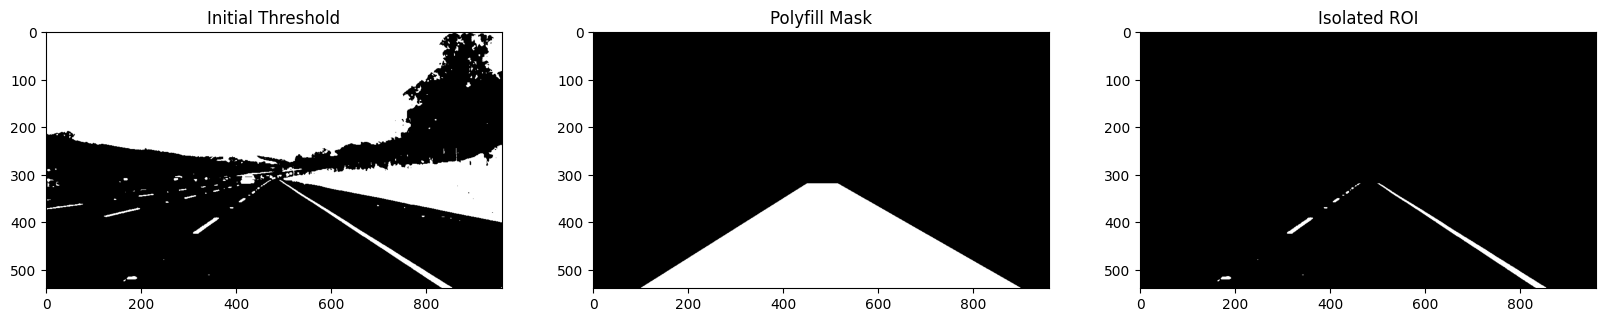

In [55]:
# Region masking
roi_vertices = np.array([[[100, 540],
                          [900, 540],
                          [515, 320],
                          [450, 320]]])

# Blank mask
mask = np.zeros_like(thresh)

# Fill color
if len(thresh.shape) > 2:
    channel_count = thresh.shape[2]
    ignore_mask_color = (255,) * channel_count
else:
    ignore_mask_color = 255

# Fill polygon
cv2.fillPoly(mask, roi_vertices, ignore_mask_color)

# Apply mask
roi = cv2.bitwise_and(thresh, mask)

# Display
plt.figure(figsize=(20,10))

plt.subplot(1,3,1)
plt.imshow(thresh, cmap='gray')
plt.title('Initial Threshold')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title('Polyfill Mask')

plt.subplot(1,3,3)
plt.imshow(roi, cmap='gray')
plt.title('Isolated ROI')

plt.show()

In [58]:
# Perform Edge Detection (using Cany)
edges = cv2.Canny(roi, 50, 150)


In [59]:
# Smooth with a Gaussian blur.
blur = cv2.GaussianBlur(roi, (5,5), 0)


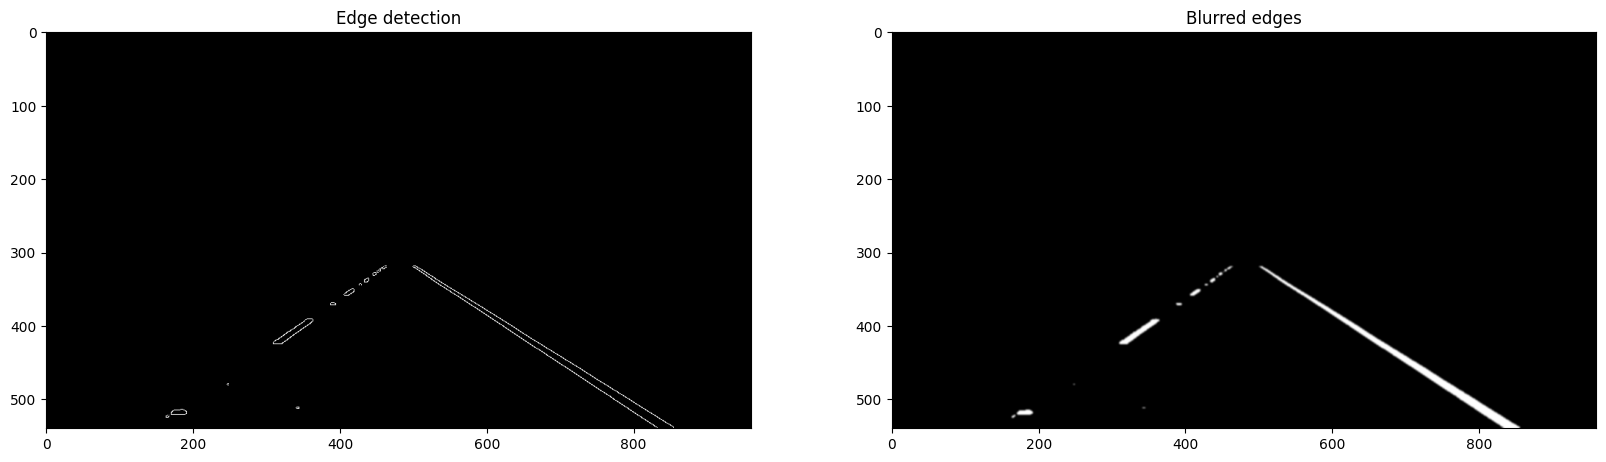

In [60]:
# Display images.
plt.figure(figsize = (20, 10))
plt.subplot(1,2,1); plt.imshow(edges, cmap = 'gray'); plt.title('Edge detection')
plt.subplot(1,2,2); plt.imshow(blur, cmap = 'gray'); plt.title('Blurred edges');



In [64]:
def draw_lines(img, lines, color = [255, 0, 0], thickness = 2):
    """Utility for drawing lines."""
    if lines is not None:
        for line in lines:
            for x1,y1,x2,y2 in line:
                cv2.line(img, (x1, y1), (x2, y2), color, thickness)

In [65]:
# Hough transform parameters set according to the input image.

rho = 1
theta = np.pi / 180
threshold = 30
min_line_length = 50
max_line_gap = 20



In [66]:
lines = cv2.HoughLinesP(edges,
                        rho,
                        theta,
                        threshold,
                        np.array([]),
                        minLineLength=min_line_length,
                        maxLineGap=max_line_gap)

In [67]:
line_image = np.copy(image)

draw_lines(line_image, lines)

Found 9 lines, including: [[503 319 854 538]]


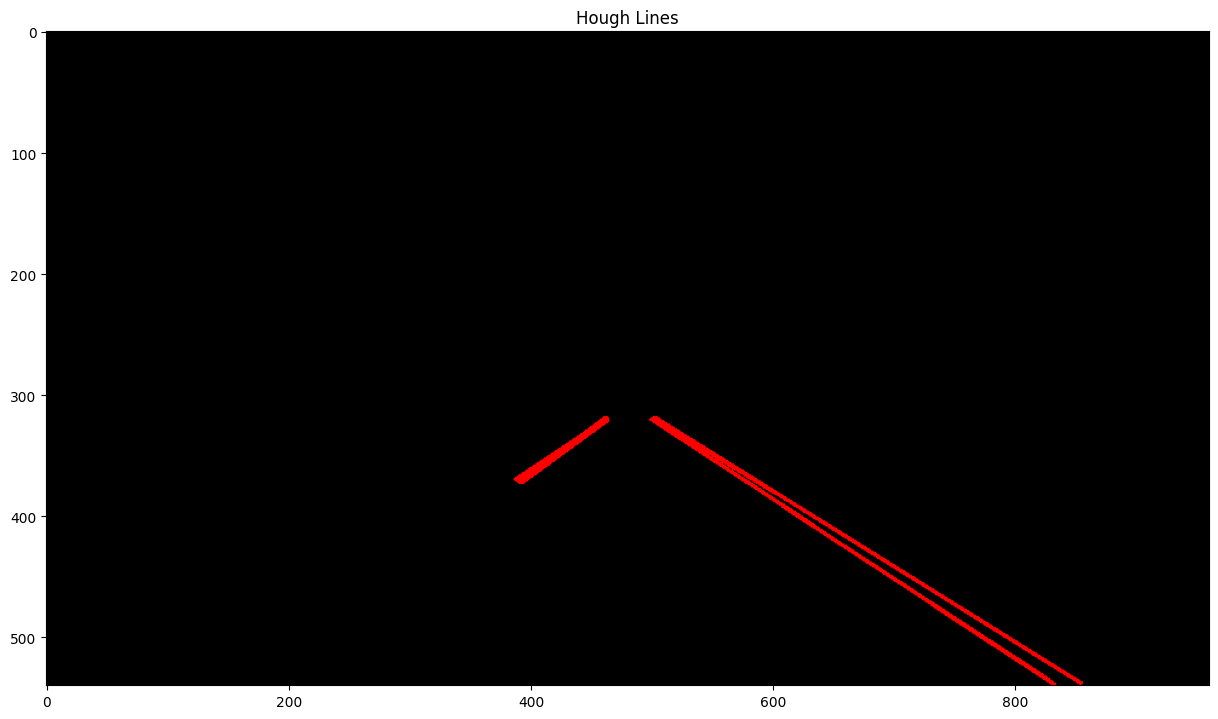

In [71]:

hough = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)

draw_lines(hough, lines)


print("Found {} lines, including: {}".format(len(lines), lines[0]))

# Display image
plt.figure(figsize=(15,10))
plt.imshow(hough)
plt.title("Hough Lines")
plt.show()

In [72]:
def separate_left_right_lines(lines):
    """Separate left and right lines depending on the slope."""
    left_lines = []
    right_lines = []
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                if y1 > y2: # Negative slope = left lane.
                    left_lines.append([x1, y1, x2, y2])
                elif y1 < y2: # Positive slope = right lane.
                    right_lines.append([x1, y1, x2, y2])
    return left_lines, right_lines

In [73]:
def cal_avg(values):
    """Calculate average value."""
    if not (type(values) == 'NoneType'):
        if len(values) > 0:
            n = len(values)
        else:
            n = 1
        return sum(values) / n

In [74]:
def extrapolate_lines(lines, upper_border, lower_border):
    """Extrapolate lines keeping in mind the lower and upper border intersections."""
    slopes = []
    consts = []
    
    if lines is not None:
        for x1, y1, x2, y2 in lines:
            slope = (y1-y2) / (x1-x2)
            slopes.append(slope)
            c = y1 - slope * x1
            consts.append(c)
    avg_slope = cal_avg(slopes)
    avg_consts = cal_avg(consts)
    
    # Calculate average intersection at lower_border.
    x_lane_lower_point = int((lower_border - avg_consts) / avg_slope)
    
    # Calculate average intersection at upper_border.
    x_lane_upper_point = int((upper_border - avg_consts) / avg_slope)
    
    return [x_lane_lower_point, lower_border, x_lane_upper_point, upper_border]

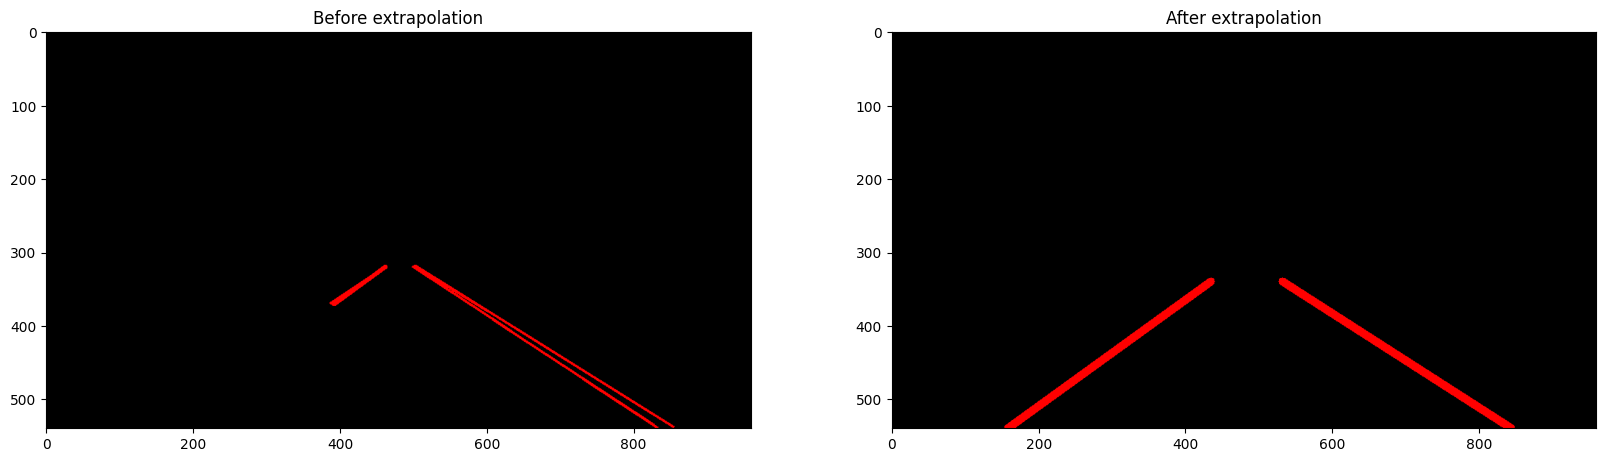

In [76]:
# Define bounds of the region of interest.
roi_upper_border = 340
roi_lower_border = 540

# Create a blank array to contain the (colorized) results.
lanes_img = np.zeros((image.shape[0], image.shape[1], 3), dtype = np.uint8)

# Use above defined function to identify lists of left-sided and right-sided lines.
lines_left, lines_right = separate_left_right_lines(lines)

# Use above defined function to extrapolate the lists of lines into recognized lanes.
lane_left = extrapolate_lines(lines_left, roi_upper_border, roi_lower_border)
lane_right = extrapolate_lines(lines_right, roi_upper_border, roi_lower_border)
draw_lines(lanes_img, [[lane_left]], thickness = 10)
draw_lines(lanes_img, [[lane_right]], thickness = 10)

# Display results.
fig = plt.figure(figsize = (20, 20))
ax = fig.add_subplot(1, 2, 1); plt.imshow(hough); ax.set_title('Before extrapolation')
ax = fig.add_subplot(1, 2, 2); plt.imshow(lanes_img); ax.set_title('After extrapolation');
plt.show()